# Práctica 3.3 - Final

Comenzamos creando el sparkContext y otros imports necesarios.
(Una vez en marcha Spark, se puede visualizar la evolución de cada trabajo de Spark en  <http://localhost:4040> )

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Ejemplo pySparkSQL") \
    .config("spark.sql.warehouse.dir", "file:///D:/tmp/spark-warehouse") \
    .getOrCreate()

sc = spark.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/03 14:08:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/03 14:08:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/03 14:08:26 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [2]:
from test_helper import Test
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pyspark.sql.functions import *

26/04/03 14:08:38 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


## 1. Regresión (Diabetes)

El objetivo de este ejercicio es entrenar un modelo de regresión en Spark para predecir el nivel de diabetes de un conjunto de pacientes. El dataset de diabetes se obtiene de scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html. Este conjunto tiene numerosas variables y la variable a predecir es el nivel de diabetes (target) que en esta mustra toma valores entre 25 y 346. 

Información sobre atributos:

- edad: edad en años
- sexo
- bmi: índice de masa corporal
- bp: presión sanguínea promedio
- s1: tc, colesterol total en suero
- s2: ldl, lipoproteínas de baja densidad
- s3: hdl, lipoproteínas de alta densidad
- s4: tch, colesterol total / HDL
- s5: ltg, logaritmo del nivel de triglicéridos en suero
- s6: glu, nivel de azúcar en sangre


In [3]:
from sklearn.datasets import load_diabetes

In [5]:
# Cargar los datos del conjunto del dataset diabetes
diabetes = load_diabetes()

# Nos quedamos en X con data y en y target
X = diabetes.data
y = diabetes.target

# Convertir las matrices NumPy en un dataframe de pandas
df_pandas = pd.DataFrame(np.hstack([X, y.reshape(-1, 1)]), columns=list(diabetes.feature_names) + ['target'])

# Convertir el dataframe de pandas en un dataframe de Spark
df = spark.createDataFrame(df_pandas)

# Número mínimo y máximo en target.
min_target, max_target = np.min(diabetes.target), np.max(diabetes.target)

In [6]:
Test.assertEquals(min_target, 25.0, "Número mínimo incorrecto")
Test.assertEquals(max_target, 346.0, "Número máximo incorrecto")

1 test passed.
1 test passed.


Una vez cargados los daros imprimimos el esquema del dataframe y visualizamos los primeros datos:

In [7]:
# Mostramos el esquema del dataset.
df.printSchema()

root
 |-- age: double (nullable = true)
 |-- sex: double (nullable = true)
 |-- bmi: double (nullable = true)
 |-- bp: double (nullable = true)
 |-- s1: double (nullable = true)
 |-- s2: double (nullable = true)
 |-- s3: double (nullable = true)
 |-- s4: double (nullable = true)
 |-- s5: double (nullable = true)
 |-- s6: double (nullable = true)
 |-- target: double (nullable = true)



In [8]:
# Enseñamos los 5 primeros valores.
df.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------+
|                 age|                 sex|                 bmi|                  bp|                  s1|                  s2|                  s3|                  s4|                  s5|                  s6|target|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------+
|0.038075906433423026| 0.05068011873981862|0.061696206518683294|  0.0218723855140367|-0.04422349842444599|-0.03482076283769895|-0.04340084565202491|-0.00259226199818...|0.019907486170462722|-0.01764612515980379| 151.0|
|-0.00188201652779...|-0.04464163650698...|-0.05147406123880...|-0.02632752814785296|-0.00844872411121...|-0.01916333974822.

### Previsualización de datos
Podemos observar cierta tendencia entre el nivel de diabetes y el índice de masa corporal. 

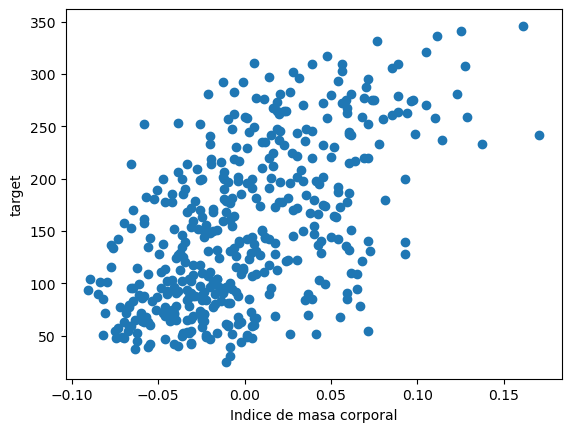

In [10]:
# Cargamos todos los datos del dataframe.
tuples = list(map(lambda row: (row["bmi"], row["target"]), df.select("bmi", "target").collect()))

# Con el siguiente plot pintamos los datos de target en relación a la variable pes
plt.scatter(list(zip(*tuples))[0], list(zip(*tuples))[1])
plt.ylabel('target')
plt.xlabel('Indice de masa corporal')
plt.show()

Graficando otras variables no se observa tan clara la tendencia. Vemos por ejemplo para la edad que no se observa una tendencia clara.

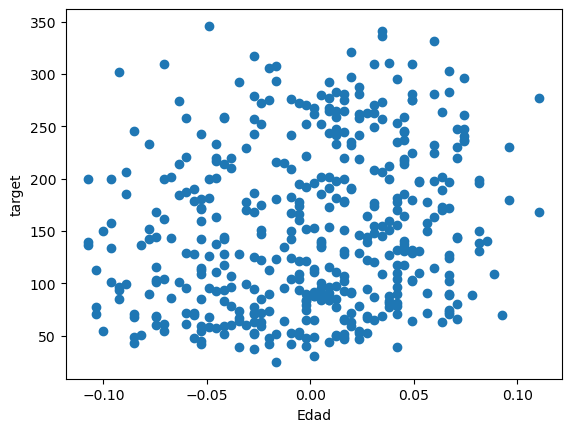

In [11]:
# Cargamos todos los datos del dataframe.
tuples = list(map(lambda row: (row["age"], row["target"]), df.select("age", "target").collect()))

# Con el siguiente plot pintamos los datos de target en relación a la variable pes
plt.scatter(list(zip(*tuples))[0], list(zip(*tuples))[1])
plt.ylabel('target')
plt.xlabel('Edad')
plt.show()

No obstante para una primera aproximación vamos a utilizar todas las variables disponibles.

Dividamos el dataframe en train y test, 70% y 30% respectivamente.

In [12]:
# Separamos con semilla 1234.
seed = 1234

# Dividir el dataset en el 70% para train y el 30% para test
(train, test) = df.randomSplit([0.7, 0.3], seed=seed)

# Cómo vamos a usar bastante este dataset lo cacheamos. ¡¡¡CUIDADO LABORATORIO VIRTUAL!!!
train.cache()

print("Tenemos %d ejemplos en training y %d en test." % (train.count(), test.count()))

Tenemos 296 ejemplos en training y 146 en test.


In [13]:
Test.assertEquals(train.count(), 296, "Número en train incorrecto")
Test.assertEquals(test.count(), 146, "Número en test incorrecto")
Test.assertEquals(train.is_cached, True, 'Training no cacheado')

1 test passed.
1 test passed.
1 test passed.


In [14]:
from pyspark.ml.feature import VectorAssembler, VectorIndexer

# Creamos el VectorAssembler y añadimos todas las variables excepto target.
input_col = df.columns
input_col.remove('target')
assembler = VectorAssembler(inputCols=input_col, outputCol="rawFeatures")

# Identificamos las características categóricas y las indexamos
vectorIndexer = VectorIndexer(inputCol="rawFeatures", outputCol="features", maxCategories=4)

### Modelo de regresión GBT 

Creamos el modelo de regresión `GBTRegressor` Gradient Boosted Trees, que combina múltiples árboles de decisión  para crear un modelo más robusto y preciso. En particular, GBTRegressor se basa en un enfoque de boosting, donde los árboles se construyen secuencialmente, y cada árbol intenta corregir los errores de los árboles anteriores en el conjunto. GBT toma un vector de características y las etiquetas como entradas y aprende un modelo de regresión que luego podremos utilizar para predecir nuevos ejemplos. Como ya hemos comentado vamos a utilizar todas las variables disponibles para entrenar el modelo de regresión.

In [15]:
from pyspark.ml.regression import GBTRegressor

# Toma las columna "features" y aprende a predecir "target"
gbt = GBTRegressor(featuresCol="features", labelCol="target")

In [16]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

# Definición del grid de parámetros para la búsqueda:
paramGrid = ParamGridBuilder()\
  .addGrid(gbt.maxDepth, [2, 5])\
  .addGrid(gbt.maxIter, [10, 20, 100, 150])\
  .build()

# Definimos una métrica para la evaluación, usando cómo métrica rmse
evaluator = RegressionEvaluator(metricName="rmse", labelCol="target", predictionCol="prediction")

# Declaramos el CrossValidator, que requiere de un estimator, un evaluator y los estimatorParamMaps (parámetros)
# Consulta http://spark.apache.org/docs/2.4.5/api/python/pyspark.ml.html#pyspark.ml.tuning.CrossValidator
cv = CrossValidator(estimator=gbt,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator,
                    numFolds=2)

Finalmente podemos unir nuestra fase de procesamiento de características con el entrenamiento del modelo en una única Pipeline con las tres fases anteriores.

In [17]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[assembler, vectorIndexer, cv])

### Entrenamiento de la Pipeline

Ahora que ya tenemos el flujo de datos definido, podemos entrenar la Pipeline completa con una única llamada a fit(). Esta llamada llevará a cabo el preprocesamiento de características, el ajuste de los parámetros y el entrenamiento del modelo final.

Como resultado obtendremos una Pipeline ajustada (PipelineModel).

In [18]:
# Entrenar la pipeline con fit y el conjunto de train
pipelineModel = pipeline.fit(train)

26/04/03 14:54:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/03 14:54:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary with size 1000.2 KiB
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary with size 1000.9 KiB
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary with size 1001.9 KiB
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary with size 1004.1 KiB
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary with size 1006.4 KiB
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary with size 1006.9 KiB
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary with size 1007.6 KiB
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary with size 1008.6 KiB
26/04/03 14:57:21 WARN DAGScheduler: Broadcasting large task binary wit

Obtenemos las predicciones en train (pred_train) y en test(pred_test):

In [19]:
pred_train = pipelineModel.transform(train)
pred_test = pipelineModel.transform(test)

Podemos ver las predicciones de unos pocos registros para intuir que tal funciona nuestro modelo.

In [20]:
pred_train.select('bmi', 'target', 'prediction').show(10)

+--------------------+------+------------------+
|                 bmi|target|        prediction|
+--------------------+------+------------------+
|-0.06764124234701265|  55.0| 94.46786737746467|
|-0.08380842345522464| 101.0| 94.46786737746467|
|-0.03638469220446948| 200.0|109.61372639045324|
|-0.04069594049999...|  97.0| 95.08366708444233|
|0.028284032228378497| 302.0|218.51091657270962|
|-0.01159501450521...| 206.0|175.96756970558323|
|-0.00405032998804...|  68.0| 97.69708631178426|
|-0.02237313524401...|  49.0| 86.03542406625776|
|-0.07303030271641665| 142.0|102.31793300488697|
|-0.01698407487461508|  90.0| 97.69708631178426|
+--------------------+------+------------------+
only showing top 10 rows



### Evaluacion

Evaluamos los resultados. Utilizaremos RMSE. 

In [35]:
# Utiliza el evaluator con su método evaluate para obtener el RMSE sobre las predicciones de train y test
rmse_train = evaluator.evaluate(pred_train)
print("RMSE en train: %g" % rmse_train)

rmse_test = evaluator.evaluate(pred_test)
print("RMSE en test: %g" % rmse_test)


RMSE en train: 48.5526
RMSE en test: 59.6889


In [37]:
Test.assertEquals(rmse_train, 48.5525888378379, "RMSE en train incorrecto")
Test.assertEquals(rmse_test, 59.6888998617071, "RMSE en test incorrecto")

1 test passed.
1 test passed.


### Modelo GBT simplificado

Vamos a simplificar el modelo eliminando algunas de las variables ya que podemos deducir que ciertas variables no aportan mucho al modelo. Por ejemplo no utilizaremos el sexo y algunos desgloses del nivel de colesterol.

In [38]:
# Creamos el VectorAssembler, nos quedamos con las variables: 'bmi', 'bp', 's4', 's5' y 's6'
input_col = ['bmi', 'bp', 's4', 's5', 's6']
assembler = VectorAssembler(inputCols=input_col, outputCol="rawFeatures")

# Identificamos las características categóricas y las indexamos 
vectorIndexer = VectorIndexer(inputCol="rawFeatures", outputCol="features", maxCategories=4)

In [39]:
from pyspark.ml.regression import GBTRegressor

# Usando GBTRegressor predecimos sobre "target"
gbt = GBTRegressor(featuresCol="features", labelCol="target")

In [40]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

# Definición del grid de parámetros para la búsqueda:
paramGrid = ParamGridBuilder()\
  .addGrid(gbt.maxDepth, [2, 5])\
  .addGrid(gbt.maxIter, [10, 20])\
  .build()

# Definimos una métrica para la evaluación
evaluator = RegressionEvaluator(metricName="rmse", labelCol=gbt.getLabelCol(), predictionCol=gbt.getPredictionCol())

# Declaramos el CrossValidator, que requiere de un estimator, un evaluator y los estimatorParamMaps (parámetros)
# Consulta http://spark.apache.org/docs/2.4.5/api/python/pyspark.ml.html#pyspark.ml.tuning.CrossValidator
cv = CrossValidator(estimator=gbt,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator,
                    numFolds=2)

In [41]:
# Creamos una Pipeline con los tres pasos anteriores.
pipeline = Pipeline(stages=[assembler, vectorIndexer, cv])

In [42]:
# Entrenar la pipeline sobre el conjunto de train
pipelineModel = pipeline.fit(train)

In [43]:
# Nuevas predicciones sobre train y test.
pred_train2 = pipelineModel.transform(train)
pred_test2 = pipelineModel.transform(test)

In [48]:
# Evaluamos RMSE del segundo modelo sobre las predicciones de la celda anterior.
rmse_train2 = evaluator.evaluate(pred_train2)
print("RMSE en train: %g" % rmse_train2)

rmse_test2 = evaluator.evaluate(pred_test2)
print("RMSE en test: %g" % rmse_test2)

RMSE en train: 49.8368
RMSE en test: 60.9826


In [49]:
Test.assertEquals(rmse_train2, 49.83675407146952, "RMSE en train incorrecto")
Test.assertEquals(rmse_test2, 60.9825859197637, "RMSE en test incorrecto")

1 test passed.
1 test passed.


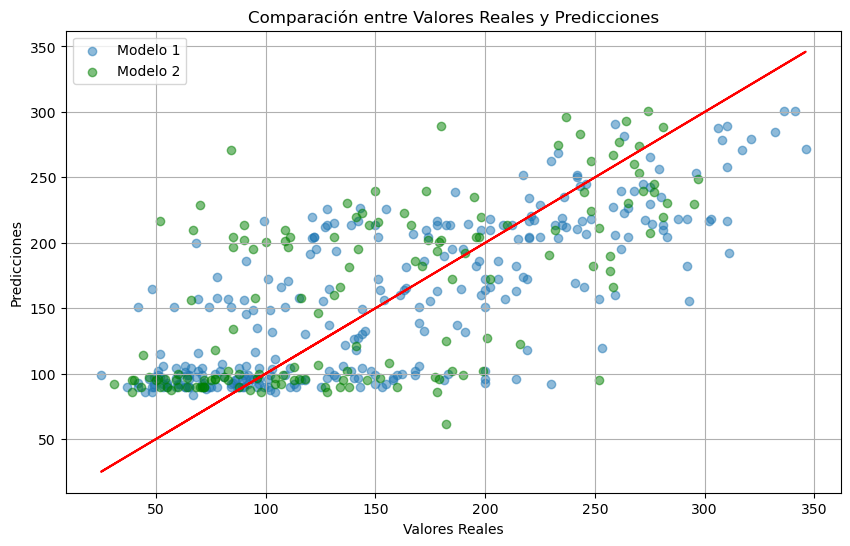

In [50]:
# Graficar los valores reales vs las predicciones en test
# En un buen ajuste los puntos graficados estarían muy próximos a la diagonal
pd_train2 = pred_train2.select("target", "prediction").toPandas()
pd_test2 = pred_test2.select("target", "prediction").toPandas()

x = pd_train2['target']
y = pd_train2['prediction']
x2 = pd_test2['target']
y2 = pd_test2['prediction']

plt.figure(figsize=(10, 6))
plt.scatter(x,y , alpha=0.5, label='Modelo 1')
plt.scatter(x2,y2 , alpha=0.5, c='green',label='Modelo 2')
plt.legend()
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.plot(x,x,color='red', linestyle='-')  # Línea diagonal
plt.title('Comparación entre Valores Reales y Predicciones')
plt.grid(True)
plt.show()

No se observan excesivas diferencias entre los 2 modelos. En el modelo mas simple se obtiene un rmse de 60.9 algo peor que en el modelo con todas las variables que era de 59.8.

Finalmente nos quedaremos con el modelo de regresión lineal ya que obtenemos un RMSE menor y un mejor ajuste tal y como se observa en el gráfico anterior.

## 2. Clasificación ( Tipos de bosque - dataset covtype )


El objetivo de este ejercicio es entrenar un modelo de clasificación en Spark para predecir el tipo de vegetación. El dataset covtype se obtiene de scikit-learn. Este conjunto es muy extenso ya que tiene 581.012 filas y también tiene numerosas variables (54). La clase a predecir tiene 7 valores posibles:

1. Spruce/Fir
2. Lodgepole Pine
3. Ponderosa Pine
4. Cottonwood/Willow
5. Aspen
6. Douglas-fir
7. Krummholz

In [51]:
from sklearn.datasets import fetch_covtype

# Cargar los datos del conjunto de datos fetch_covtype
covtype = fetch_covtype()

# Los separamos en X (data) e y (target).
X = covtype.data
y = covtype.target

In [52]:
Test.assertEquals(X.shape, (581012, 54), "Carga de datos incorrecta")

1 test passed.


Podemos observar que tenemos 581.012 registros/filas y 54 variables/columnas. Como son muchas variables no vamos a realizar un analisis detallado del significado de éstas. 

Las 4 primeras variables por ejemplo son las siguientes:

* Elevation (Elevación): Es la elevación en metros sobre el nivel del mar. Esta característica indica la altitud del terreno en la ubicación dada.

* Aspect (Orientación): Se refiere a la dirección hacia la cual está orientada una pendiente. Se mide en grados, representando el ángulo con respecto al norte en sentido horario.

* Slope (Pendiente): Es la inclinación del terreno en grados. Indica la tasa de cambio en la elevación con respecto a la distancia horizontal.

* Horizontal_Distance_To_Hydrology (Distancia horizontal a hidrología): Es la distancia horizontal desde el punto en cuestión hasta la característica de hidrología más cercana, como un río o un arroyo, medida en metros.



Los tipos de bosque son 7, por lo tanto númeramos las clases del 1 a 7.

In [55]:
class_labels = covtype.target
unique_class_labels = np.unique(class_labels)
print("Clases:", unique_class_labels)

Clases: [1 2 3 4 5 6 7]


Como tenemos muchos registros y el laboratorio virtual no responde de manera ágil vamos a seleccionar de forma estratificada el 1 % de los registros y crear un dataframe en spark con ellos. 

In [57]:
from sklearn.model_selection import train_test_split

# Para las pruebas nos quedamos con el 1% de los datos, estratificados por y (variable objetivo)
Xred, _, yred, _ = train_test_split(X, y, train_size=0.01, stratify=y, random_state=1234)

# Convertir las matrices NumPy en un dataframe de pandas
# En lugar de usar como nombre de etiqueta 'Cover_Type' usaremos 'class'
df = pd.DataFrame(np.hstack([Xred, yred.reshape(-1, 1)]), columns=covtype.feature_names + ['class'])

# Convertir el dataframe de pandas en un dataframe de Spark
df = spark.createDataFrame(df)

Podemos comprobar que el dataframe reducido con el 1% de los datos tiene la misma distribución en cuanto a porcentaje de cada clase que el original

In [58]:
# Obtener los nombres únicos de las etiquetas de clase y sus frecuencias
unique_classes, class_counts = np.unique(y, return_counts=True)
unique_classes_red, class_counts_red = np.unique(yred, return_counts=True)

# Imprimir los nombres de las clases y la cantidad de registros para cada clase
for class_label, class_count, class_count_red in zip(unique_classes, class_counts, class_counts_red):
    print(f"Clase {class_label}: {np.round(class_count/y.shape[0]*100)} % registros conjunto total / {np.round(class_count_red/yred.shape[0]*100)} % registros conjunto reducido")


Clase 1: 36.0 % registros conjunto total / 36.0 % registros conjunto reducido
Clase 2: 49.0 % registros conjunto total / 49.0 % registros conjunto reducido
Clase 3: 6.0 % registros conjunto total / 6.0 % registros conjunto reducido
Clase 4: 0.0 % registros conjunto total / 0.0 % registros conjunto reducido
Clase 5: 2.0 % registros conjunto total / 2.0 % registros conjunto reducido
Clase 6: 3.0 % registros conjunto total / 3.0 % registros conjunto reducido
Clase 7: 4.0 % registros conjunto total / 4.0 % registros conjunto reducido


Visualizamos uno de los registros del Dataframe

In [59]:
df.show(1)

26/04/03 15:17:17 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------+------+-----+--------------------------------+------------------------------+-------------------------------+-------------+--------------+-------------+----------------------------------+-----------------+-----------------+-----------------+-----------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+-----+
|Elevation|Aspect|Slope|Horizontal_Distance_To_Hydrology|Vertical_Distance_To_Hydrology|Horizontal_Distance_To_Roadways|Hillshade_9am|Hillshade_Noon|Hillshade_3pm|Horizontal_Distance_To_Fire_Points|Wilderness_Area

Dividimos el dataframe en train y test, 70% y 30% respectivamente. Cacheamos en conjunto de train para tener mas accesibles los datos que vamos a reutilizar en los distintos entrenamientos de modelos.

In [60]:
# Separamos con semilla 1234 y cacheamos train.
seed = 1234
(train, test) = df.randomSplit([0.7, 0.3], seed=seed)
train.cache()

DataFrame[Elevation: double, Aspect: double, Slope: double, Horizontal_Distance_To_Hydrology: double, Vertical_Distance_To_Hydrology: double, Horizontal_Distance_To_Roadways: double, Hillshade_9am: double, Hillshade_Noon: double, Hillshade_3pm: double, Horizontal_Distance_To_Fire_Points: double, Wilderness_Area_0: double, Wilderness_Area_1: double, Wilderness_Area_2: double, Wilderness_Area_3: double, Soil_Type_0: double, Soil_Type_1: double, Soil_Type_2: double, Soil_Type_3: double, Soil_Type_4: double, Soil_Type_5: double, Soil_Type_6: double, Soil_Type_7: double, Soil_Type_8: double, Soil_Type_9: double, Soil_Type_10: double, Soil_Type_11: double, Soil_Type_12: double, Soil_Type_13: double, Soil_Type_14: double, Soil_Type_15: double, Soil_Type_16: double, Soil_Type_17: double, Soil_Type_18: double, Soil_Type_19: double, Soil_Type_20: double, Soil_Type_21: double, Soil_Type_22: double, Soil_Type_23: double, Soil_Type_24: double, Soil_Type_25: double, Soil_Type_26: double, Soil_Type_2

In [61]:
input_col = df.columns 
input_col.remove('class') 
assembler = VectorAssembler(inputCols=input_col, outputCol="rawFeatures")

# Identificamos las características categóricas y las indexamos 
vectorIndexer = VectorIndexer(inputCol="rawFeatures", outputCol="features", maxCategories=4)

In [62]:
from pyspark.ml.classification import LogisticRegression

# Regresión logística con 20 iteraciones y parámetro de regularización = 0.01
lr = LogisticRegression(maxIter=20, regParam=0.01, featuresCol='features', labelCol='class', predictionCol='prediction')

# Creamos la pipeline como una lista de fases
pipeline = Pipeline(stages=[assembler, vectorIndexer, lr])

Entrenamiento del modelo

In [63]:
spark.sparkContext.setLogLevel("ERROR")
model = pipeline.fit(train)

Obtenemos las predicciones en train y test

In [64]:
predictionTrain = model.transform(train)
predictionTest = model.transform(test)

In [65]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
multi_evaluator = MulticlassClassificationEvaluator(predictionCol='prediction',labelCol='class')

# Utiliza el evaluador creado
# Calcular precision, recall y F-score en train y test
train_precision = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "weightedPrecision"})
train_recall = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "weightedRecall"})
train_f1score = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "f1"})                                        
test_precision = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "weightedPrecision"})
test_recall = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "weightedRecall"})
test_f1score = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "f1"})


In [66]:
# Imprimir las métricas
print('Train Precision:', train_precision)
print('Train Recall:', train_recall)
print('Train F1-score:', train_f1score)

print("\n")

print('Test Precision:', test_precision)
print('Test Recall:', test_recall)
print('Test F1-score:', test_f1score)

Train Precision: 0.6934056463456587
Train Recall: 0.7126436781609197
Train F1-score: 0.6927840220054696


Test Precision: 0.693540443398652
Test Recall: 0.7135386403253923
Test F1-score: 0.6972500908526631


Vamos a intentar mejorar nuestro modelo con ajuste de hiperparametros mediante validación cruzada 

In [67]:
lr = LogisticRegression(featuresCol='features', labelCol='class', predictionCol='prediction')
input_col = df.columns 
input_col.remove('class') 
assembler = VectorAssembler(inputCols=input_col, outputCol="features")

# En este caso utilizaremos un pipeline sin vectorIndexer
pipeline = Pipeline(stages=[assembler, lr])

# evaluador de multiclase con métrica weightedRecall
evaluator = MulticlassClassificationEvaluator(predictionCol='prediction',labelCol='class',metricName='f1')

In [68]:
from pyspark.ml.tuning import ParamGridBuilder,CrossValidator
paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.01, 0.1, 0.2])
             .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
             .addGrid(lr.maxIter, [10, 50, 100,500])
             .addGrid(lr.threshold, [0.4, 0.5, 0.6])
             .addGrid(lr.fitIntercept, [True, False])
             .build())

In [69]:
# Llamamos el validaro cruzado.
cv = CrossValidator(estimator=pipeline,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator,
                    numFolds=2)

# Entrenamos el modelo.
cvModel = cv.fit(train)

Obtenemos las predicciones en train y test

In [70]:
predictionTrain = cvModel.transform(train)
predictionTest = cvModel.transform(test)

In [71]:
train_precision = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "weightedPrecision"})
train_recall = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "weightedRecall"})
train_f1score = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "f1"})                                        
test_precision = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "weightedPrecision"})
test_recall = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "weightedRecall"})
test_f1score = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "f1"})

In [72]:
# Imprimir las métricas
print('Train Precision:', train_precision)
print('Train Recall:', train_recall)
print('Train F1-score:', train_f1score)
print("\n")
print('Test Precision:', test_precision)
print('Test Recall:', test_recall)
print('Test F1-score:', test_f1score)

Train Precision: 0.6906371833921356
Train Recall: 0.7119100024455857
Train F1-score: 0.6919127150224486


Test Precision: 0.6913169516720291
Test Recall: 0.7117954677513074
Test F1-score: 0.695833804098663


In [73]:
# Extraemos los parametros del modelo optimizado mediante cv
paramMap = cvModel.bestModel.stages[1].extractParamMap()

# Imprimimos los resultados.
print("Parametros del modelo:")
for param, value in paramMap.items():
    print('Parametro', param.name, ':', value)

Parametros del modelo:
Parametro aggregationDepth : 2
Parametro elasticNetParam : 0.0
Parametro family : auto
Parametro featuresCol : features
Parametro fitIntercept : True
Parametro labelCol : class
Parametro maxBlockSizeInMB : 0.0
Parametro maxIter : 100
Parametro predictionCol : prediction
Parametro probabilityCol : probability
Parametro rawPredictionCol : rawPrediction
Parametro regParam : 0.01
Parametro standardization : True
Parametro threshold : 0.4
Parametro tol : 1e-06


Con un modelo optimizado mediante validación cruzada conseguimos una pequeña mejora pasando en test a un F1-score de cerca de 0,7. 

Los hiperparametros elegidos mediante validación cruzada son:
* regParam: 0.01
* elasticNetParam: 0.0
* maxIter: 500
* threshold: 0.6
* fitIntercept: True

NOTA:

Una vez testeado nuestro modelo podriamos aprovechar el potencial de spark realizando el entrenamiento con la totalidad de los datos (581.012 registros) ya que para el ejercicio solo hemos utilizado el 1% de los mismos debido a las limitaciones del laboratorio virtual.  

### Clasificación  PCA + Regresión logística

Vamos a entrenar otro modelo. Creamos una pipeline que utiliza el assembler, PCA con 20 componentes principales y regresión logística. 

In [74]:
from pyspark.ml.feature import PCA

# assembler
assembler = VectorAssembler(inputCols=input_col, outputCol="features")

# Número de componentes para PCA 
num_components = 20
pca = PCA(k=num_components, inputCol="features", outputCol="pca_features")

# Regresión logística con 20 iteraciones y parámetro de regularización = 0.01
lr = LogisticRegression(maxIter=500, regParam=0.01, featuresCol='pca_features', labelCol='class', predictionCol='prediction')

# Crear el pipeline
pipeline = Pipeline(stages=[assembler, pca, lr])

# Entrenamiento
pipeline_model = pipeline.fit(train)

# Predicciones
predictionTrain = pipeline_model.transform(train)
predictionTest = pipeline_model.transform(test)

In [75]:
train_precision = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "weightedPrecision"})
train_recall = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "weightedRecall"})
train_f1score = multi_evaluator.evaluate(predictionTrain, {multi_evaluator.metricName: "f1"})                                        
test_precision = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "weightedPrecision"})
test_recall = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "weightedRecall"})
test_f1score = multi_evaluator.evaluate(predictionTest, {multi_evaluator.metricName: "f1"})

In [76]:
# Imprimir las métricas
print('Train Precision:', train_precision)
print('Train Recall:', train_recall)
print('Train F1-score:', train_f1score)
print("\n")
print('Test Precision:', test_precision)
print('Test Recall:', test_recall)
print('Test F1-score:', test_f1score)

Train Precision: 0.671413475098205
Train Recall: 0.6916116409880165
Train F1-score: 0.6668430641178413


Test Precision: 0.6906774977304209
Test Recall: 0.7036606624055782
Test F1-score: 0.6827315329621504


Con PCA se ha logrado simplificar el modelo, lo que puede mejorar la eficiencia computacional y reducir el riesgo de sobreajuste. Sin embargo, perdemos capacidad predictiva del modelo.